In [1]:
import pandas as pd
# All datasets names
from math_arena_datasets import output_datasets_2025

In [ ]:
from typing import Any
from datasets import DatasetDict
data_dict: dict[str, DatasetDict] = {}
from datasets import load_dataset

for dataset_name in output_datasets_2025:
  
  data_dict[dataset_name] = load_dataset(f"{dataset_name}")



In [3]:
all_column_names = set()
for name, dataset in data_dict.items():
  cols = dataset["train"].column_names
  all_column_names = all_column_names.union(cols )
  
all_column_names


{'__index_level_0__',
 'answer',
 'correct',
 'cost',
 'error_judge_1',
 'error_judge_2',
 'gold_answer',
 'grading_details_judge_1',
 'grading_details_judge_2',
 'idx_answer',
 'image',
 'input_cost_per_tokens',
 'input_tokens',
 'max_points_judge_1',
 'max_points_judge_2',
 'model_config',
 'model_name',
 'output_cost_per_tokens',
 'output_tokens',
 'parsed_answer',
 'points_judge_1',
 'points_judge_2',
 'problem',
 'problem_idx',
 'source',
 'user_message'}

In [10]:
from datasets import DatasetDict
def pick_dict_elment(n: int, d: dict[DatasetDict]) -> tuple[str, DatasetDict]: 
  i = 0
  for k,_ in d.items():
    if i==n:
      return k, d[k]

ex_name, ex_dataset = pick_dict_elment(0, data_dict)


ex_dataset["train"].to_pandas()

,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,input_cost_per_tokens,output_cost_per_tokens,source,gold_answer,parsed_answer,correct,__index_level_0__
0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,22492,0.337827,3.0,15.0,IMO 2025 P6,2112,4048,False,0
1,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,1,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,18982,0.285177,3.0,15.0,IMO 2025 P6,2112,4048,False,1
2,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,2,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,25824,0.387807,3.0,15.0,IMO 2025 P6,2112,4048,False,2
3,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,3,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,22835,0.342972,3.0,15.0,IMO 2025 P6,2112,4048,False,3
4,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,4,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,21121,0.317262,3.0,15.0,IMO 2025 P6,2112,4048,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,11,"Please reason step by step, and put your final...","The value of \(k(n,p)\) is the \(p\)-adic valu...",144,6932,0.104412,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2539
1904,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,12,"Please reason step by step, and put your final...","The value of \(k(n,p)\) is the \(p\)-adic valu...",144,5347,0.080637,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2540
1905,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,13,"Please reason step by step, and put your final...","The value of \(k(n,p)\) is the \(p\)-adic valu...",144,4700,0.070932,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2541
1906,6,Let $n$ be a positive integer and $p$ be a pri...,Grok 4,xai/grok-4,14,"Please reason step by step, and put your final...",\boxed{8},144,21562,0.323862,3.0,15.0,ELMO Shortlist 2025 N7,138,8,False,2542


In [ ]:
UNIQUE_PROBLEM_LABEL = "unique_problem_label"
PROBLEM_IDX = "problem_idx"
all_data = []
for k, d in data_dict.items():
  df: pd.DataFrame = d["train"].to_pandas()
  df["unique_problem_label"] = df[PROBLEM_IDX].map(lambda x : f"{k}: {x}")
  all_data.append(df)
data_path = "data/all_answers_pd/all_answers.csv"
# save the data
# pd.concat(all_data).to_csv(data_path)

In [32]:
df = pd.read_csv(data_path)

In [33]:
missing_ratio = df.isna().mean()
missing_ratio

Unnamed: 0                 0.000000
problem_idx                0.000000
problem                    0.172297
model_name                 0.000000
model_config               0.000000
idx_answer                 0.000000
user_message               0.000000
answer                     0.000000
input_tokens               0.000000
output_tokens              0.000000
cost                       0.000000
input_cost_per_tokens      0.000000
output_cost_per_tokens     0.000000
source                     0.938850
gold_answer                0.014038
parsed_answer              0.020031
correct                    0.014038
__index_level_0__          0.938850
unique_problem_label       0.000000
points_judge_1             0.985962
grading_details_judge_1    0.985962
error_judge_1              0.992340
max_points_judge_1         0.985962
points_judge_2             0.988078
grading_details_judge_2    0.988078
error_judge_2              0.992436
max_points_judge_2         0.988078
image                      0

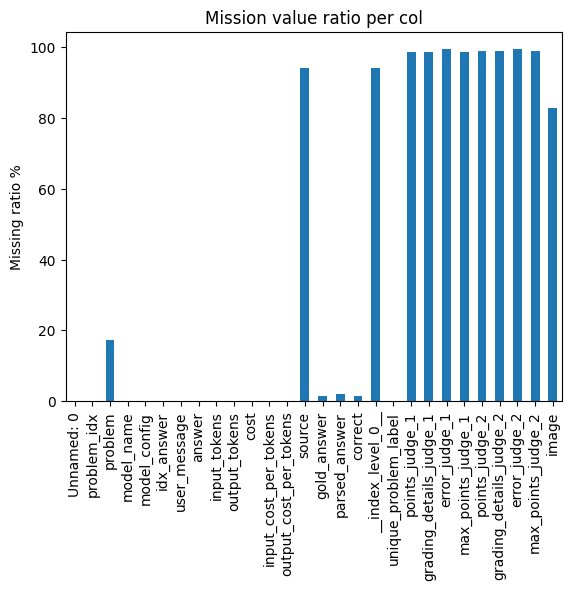

In [34]:
import matplotlib.pyplot as plt 
(missing_ratio*100).plot.bar()
plt.ylabel("Missing ratio %")
plt.title("Mission value ratio per col")
plt.show()

## Drop colulumn with missing value ration over 10%

In [40]:
cols_to_keep = []
for col, ratio in missing_ratio.to_dict().items():
  if ratio<=0.1:
    cols_to_keep.append(col)

df_pruned = df[cols_to_keep].reset_index()
df_pruned = df_pruned.drop(["Unnamed: 0"], axis=1)
df_pruned

,index,problem_idx,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,input_cost_per_tokens,output_cost_per_tokens,gold_answer,parsed_answer,correct,unique_problem_label
0,0,12,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,22492.0,0.337827,3.0,15.0,2112,4048,False,MathArena/apex_2025_outputs: 12
1,1,12,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,1,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,18982.0,0.285177,3.0,15.0,2112,4048,False,MathArena/apex_2025_outputs: 12
2,2,12,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,2,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,25824.0,0.387807,3.0,15.0,2112,4048,False,MathArena/apex_2025_outputs: 12
3,3,12,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,3,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,22835.0,0.342972,3.0,15.0,2112,4048,False,MathArena/apex_2025_outputs: 12
4,4,12,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,4,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,21121.0,0.317262,3.0,15.0,2112,4048,False,MathArena/apex_2025_outputs: 12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31197,31197,10,Grok 4,xai/grok-4,3,"[{'type': 'text', 'text': 'You are given a Mat...",\boxed{A},1847.0,17160.0,0.262941,3.0,15.0,E,A,False,MathArena/kangaroo_2025_11-12_outputs: 10
31198,31198,6,Grok 4,xai/grok-4,0,"[{'type': 'text', 'text': 'You are given a Mat...",\boxed{D},1847.0,16833.0,0.258036,3.0,15.0,A,D,False,MathArena/kangaroo_2025_11-12_outputs: 6
31199,31199,6,Grok 4,xai/grok-4,1,"[{'type': 'text', 'text': 'You are given a Mat...",\boxed{E},1847.0,18951.0,0.289806,3.0,15.0,A,E,False,MathArena/kangaroo_2025_11-12_outputs: 6
31200,31200,6,Grok 4,xai/grok-4,2,"[{'type': 'text', 'text': 'You are given a Mat...",\boxed{E},1847.0,22433.0,0.342036,3.0,15.0,A,E,False,MathArena/kangaroo_2025_11-12_outputs: 6


In [42]:
CORRECT = "correct"
grouped = df_pruned.groupby(UNIQUE_PROBLEM_LABEL)[CORRECT].mean()
grouped

unique_problem_label
MathArena/aime_2025_II_outputs: 1     0.959677
MathArena/aime_2025_II_outputs: 10    0.580645
MathArena/aime_2025_II_outputs: 11    0.403226
MathArena/aime_2025_II_outputs: 12    0.717742
MathArena/aime_2025_II_outputs: 13    0.169355
                                        ...   
MathArena/usamo_2025_outputs: 2            NaN
MathArena/usamo_2025_outputs: 3            NaN
MathArena/usamo_2025_outputs: 4            NaN
MathArena/usamo_2025_outputs: 5            NaN
MathArena/usamo_2025_outputs: 6            NaN
Name: correct, Length: 359, dtype: object

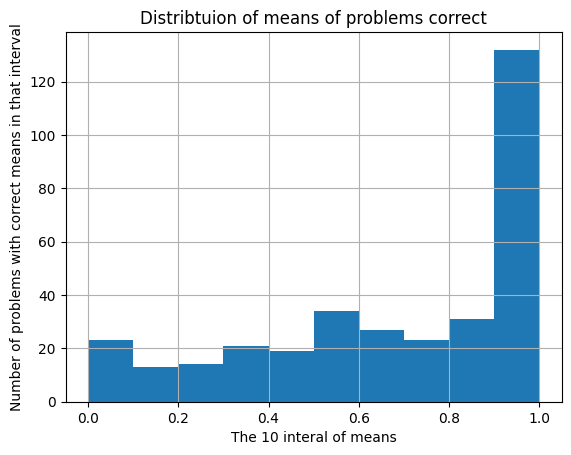

In [ ]:
bins = 10
grouped.hist(bins=bins)
plt.xlabel(f"The {bins} interval of means")
plt.ylabel("Number of problems with correct means in that interval")
plt.title("Distribtuion of means of problems correct")
plt.show()

1.0